# CPU-Optimized INT8 1D CNN Model Training & Microcontroller Export Pipeline

This notebook implements an end-to-end, **CPU-optimized and memory-safe** 1D Convolutional Neural Network (CNN) training and INT8 quantization pipeline for intraoperative adverse event prediction (Hypotension, Hypoxia, Tachycardia).

### Key Technical Features:
1. **Self-Healing Environment**: Auto-detects and installs TensorFlow in the active Jupyter kernel if missing or corrupted.
2. **Confusion Matrix Generation**: Computes per-epoch Confusion Matrices and plots final Seaborn heatmaps for all 3 targets.
3. **Thread & CPU Parallelism Control**: Configures `inter_op` & `intra_op` threads to prevent CPU thrashing.
4. **RAM Footprint Reduction**: Stores in-memory feature matrices as 1-byte signed `int8` (`[-128, 127]`), saving 75% RAM.
5. **Isolated INT8 Export**: Saves all scaler parameters, confusion matrix plots, and quantized TFLite models into `CNN/models_int8/`.

## 0. Self-Healing Dependency & TensorFlow Installation Check

In [ ]:
# Automatic Dependency & Environment Repair for Jupyter Kernel
import sys
import subprocess

try:
    import tensorflow as tf
    from tensorflow.python import pywrap_tensorflow
    print(f'[Kernel Check] TensorFlow {tf.__version__} is correctly installed and ready.')
except (ImportError, ModuleNotFoundError, AttributeError) as e:
    print(f'[Kernel Warning] TensorFlow issue detected ({e}). Repairing package in current kernel...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', 'tensorflow'])
    import tensorflow as tf
    print(f'[Kernel Success] TensorFlow successfully installed/repaired: v{tf.__version__}')

## 1. CPU Environment & Thread Optimization

In [8]:
import os
import glob
import json
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CPU Parallelism & Memory Safety Settings
os.environ['OMP_NUM_THREADS'] = '4'
os.environ['MKL_NUM_THREADS'] = '4'

import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score

tf.config.threading.set_inter_op_parallelism_threads(2)
tf.config.threading.set_intra_op_parallelism_threads(4)

# Output directory for INT8 models
MODEL_OUTPUT_DIR = 'models_int8'
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)
print(f'[CPU Setup] CPU thread optimization active. Model directory: {MODEL_OUTPUT_DIR}')

[CPU Setup] CPU thread optimization active. Model directory: models_int8


## 2. Configuration & 500-Patient Dataset Indexing

In [9]:
# --- CPU-Optimized Hyperparameters ---
WINDOW_SIZE = 600
STRIDE = 10         # Stride 10s for fast CPU training and memory safety
EPOCHS = 8          # 8 Epochs for high efficiency
BATCH_SIZE = 128    # Optimal CPU cache batch size
MAX_TRAIN = 500     # 500 Patient records
MAX_VAL = 100
MAX_WINDOWS_PER_PATIENT = 300  # Cap per patient to prevent RAM overload

# Resolve process_labeled_data path
possible_paths = [
    '../process_labeled_data',
    'process_labeled_data',
    '/home/logan78/Desktop/SiLabs/process_labeled_data'
]
input_dir = next((p for p in possible_paths if os.path.exists(p)), 'process_labeled_data')
csv_files = sorted(glob.glob(os.path.join(input_dir, 'patient_*_1hz.csv')))
print(f'[Dataset] Found {len(csv_files)} patient records in: {input_dir}')

# 19 Features (9 Base Vitals + 10 Engineered Derivatives)
base_features = [
    'Solar8000/HR', 'Solar8000/ART_SBP', 'Solar8000/ART_DBP', 'Solar8000/ART_MBP',
    'Solar8000/PLETH_SPO2', 'Solar8000/RR_CO2', 'Solar8000/ETCO2', 'Primus/FIO2', 'Solar8000/BT'
]
engineered_features = [
    'Feature_Pulse_Pressure', 'Feature_Shock_Index', 'Feature_Modified_Shock_Index',
    'Feature_Rate_Pressure_Product', 'Feature_HR_Mean_60s', 'Feature_HR_Std_60s',
    'Feature_HR_Delta_60s', 'Feature_MBP_Mean_60s', 'Feature_MBP_Std_60s', 'Feature_MBP_Delta_60s'
]
features = base_features + engineered_features

train_val_files, test_files = train_test_split(csv_files[:MAX_TRAIN + MAX_VAL], test_size=0.15, random_state=42, shuffle=True)
train_files, val_files = train_test_split(train_val_files, test_size=0.15, random_state=42, shuffle=True)
train_files = train_files[:MAX_TRAIN]
val_files = val_files[:MAX_VAL]

print(f'[Dataset Split] Train: {len(train_files)} patients | Val: {len(val_files)} patients | Test: {len(test_files)} patients')

[Dataset] Found 3764 patient records in: ../process_labeled_data
[Dataset Split] Train: 433 patients | Val: 77 patients | Test: 90 patients


## 3. Global INT8 Quantization Scaler Computation

In [10]:
print('[INT8 Scaler] Computing global feature min/max and INT8 quantization parameters...')
scaler_data = []
for file in train_files[:200]:  # Subsample 200 patients for fast & robust scaler calculation
    try:
        df = pd.read_csv(file, usecols=lambda c: c in features)
        avail = [c for c in features if c in df.columns]
        if len(avail) == len(features):
            scaler_data.append(df[features].ffill().bfill().fillna(0).values.astype(np.float32))
    except Exception:
        continue

stacked = np.vstack(scaler_data)
feat_min = np.percentile(stacked, 0.1, axis=0)
feat_max = np.percentile(stacked, 99.9, axis=0)
feat_mean = np.mean(stacked, axis=0)
feat_var = np.var(stacked, axis=0)

del stacked, scaler_data
gc.collect()

# Affine INT8 Scaling: float -> [-128, 127]
int8_scale = (feat_max - feat_min) / 255.0
int8_scale = np.where(int8_scale == 0, 1e-5, int8_scale)
int8_zero_point = np.round(-128 - (feat_min / int8_scale)).astype(np.int32)
int8_zero_point = np.clip(int8_zero_point, -128, 127)

def float_to_int8(x_float):
    q_val = np.round((x_float / int8_scale) + int8_zero_point)
    return np.clip(q_val, -128, 127).astype(np.int8)

def int8_to_float(x_int8):
    return ((x_int8.astype(np.float32) - int8_zero_point) * int8_scale).astype(np.float32)

scaler_dict = {
    'features': features,
    'int8_scale': {feat: float(int8_scale[i]) for i, feat in enumerate(features)},
    'int8_zero_point': {feat: int(int8_zero_point[i]) for i, feat in enumerate(features)},
    'min': {feat: float(feat_min[i]) for i, feat in enumerate(features)},
    'max': {feat: float(feat_max[i]) for i, feat in enumerate(features)},
    'mean': {feat: float(feat_mean[i]) for i, feat in enumerate(features)},
    'variance': {feat: float(feat_var[i]) for i, feat in enumerate(features)}
}

scaler_json_path = os.path.join(MODEL_OUTPUT_DIR, 'scaler_1d_cnn_int8.json')
with open(scaler_json_path, 'w') as f:
    json.dump(scaler_dict, f, indent=4)
print(f'[INT8 Scaler] Saved quantization parameters to: {scaler_json_path}')

[INT8 Scaler] Computing global feature min/max and INT8 quantization parameters...
[INT8 Scaler] Saved quantization parameters to: models_int8/scaler_1d_cnn_int8.json


## 4. RAM-Efficient INT8 Sequence Generator & CPU 1D CNN Architecture

In [11]:
class Int8WindowDataGenerator(keras.utils.Sequence):
    def __init__(self, file_list, target_col, features, batch_size=128, window_size=600, stride=10, max_windows=300, shuffle=True):
        self.batch_size = batch_size
        self.window_size = window_size
        self.stride = stride
        self.shuffle = shuffle
        self.X_int8 = []
        self.y_data = []
        self.window_indices = []
        
        for file_idx, file in enumerate(file_list):
            try:
                df = pd.read_csv(file, usecols=lambda c: c in features or c == target_col)
                avail = [c for c in features if c in df.columns]
                if len(avail) < len(features) or target_col not in df.columns:
                    continue
                df_sub = df[avail + [target_col]].ffill().bfill().fillna(0)
                raw_float = df_sub[avail].values.astype(np.float32)
                y_vals = df_sub[target_col].values.astype(np.float32)
                arr_int8 = float_to_int8(raw_float)
                self.X_int8.append(arr_int8)
                self.y_data.append(y_vals)
                
                patient_wins = 0
                for i in range(0, len(arr_int8) - window_size, stride):
                    if not np.isnan(y_vals[i + window_size - 1]):
                        self.window_indices.append((file_idx, i))
                        patient_wins += 1
                        if patient_wins >= max_windows:
                            break
            except Exception:
                continue
        self.indices = np.arange(len(self.window_indices))
        if self.shuffle:
            np.random.shuffle(self.indices)
            
    def __len__(self):
        return int(np.ceil(len(self.window_indices) / self.batch_size))
        
    def __getitem__(self, idx):
        batch_inds = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        X_batch_int8 = np.empty((len(batch_inds), self.window_size, len(features)), dtype=np.int8)
        y_batch = np.empty((len(batch_inds),), dtype=np.float32)
        for i, b_idx in enumerate(batch_inds):
            file_idx, start = self.window_indices[b_idx]
            X_batch_int8[i] = self.X_int8[file_idx][start : start + self.window_size]
            y_batch[i] = self.y_data[file_idx][start + self.window_size - 1]
        return int8_to_float(X_batch_int8), y_batch
        
    def get_all_y(self):
        y_all = np.empty(len(self.window_indices), dtype=np.float32)
        for i, w_idx in enumerate(self.window_indices):
            file_idx, start = w_idx
            y_all[i] = self.y_data[file_idx][start + self.window_size - 1]
        return y_all

# Epoch-End Confusion Matrix Callback
class EpochEndCallback(keras.callbacks.Callback):
    def __init__(self, val_gen, target):
        super().__init__()
        self.val_gen = val_gen
        self.target = target
        
    def on_epoch_end(self, epoch, logs=None):
        y_true = self.val_gen.get_all_y()
        y_pred_prob = self.model.predict(self.val_gen, verbose=0).flatten()
        best_thresh = 0.5
        best_f1 = 0
        for thresh in np.arange(0.3, 0.8, 0.05):
            y_pred = (y_pred_prob > thresh).astype(int)
            score = f1_score(y_true, y_pred, zero_division=0)
            if score > best_f1:
                best_f1 = score
                best_thresh = thresh
        cm = confusion_matrix(y_true, (y_pred_prob > best_thresh).astype(int))
        print(f'\n--- Epoch {epoch+1} [{self.target}] Confusion Matrix (Optimal Threshold: {best_thresh:.2f}, F1: {best_f1:.4f}) ---')
        print(cm)

# CPU-Optimized 1D CNN Architecture
def get_compiled_model(target_name):
    dropout_rate = 0.5 if target_name == 'Future_Hypoxia' else 0.3
    inputs = keras.Input(shape=(WINDOW_SIZE, len(features)))
    norm_layer = keras.layers.Normalization(mean=feat_mean, variance=feat_var)
    x = norm_layer(inputs)
    x = keras.layers.Conv1D(16, 5, strides=2, activation='relu', padding='same', kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = keras.layers.MaxPool1D(2)(x)
    x = keras.layers.Conv1D(32, 5, strides=2, activation='relu', padding='same', kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = keras.layers.MaxPool1D(2)(x)
    x = keras.layers.Conv1D(32, 5, strides=2, activation='relu', padding='same', kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = keras.layers.GlobalAveragePooling1D()(x)
    x = keras.layers.Dropout(dropout_rate)(x)
    outputs = keras.layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc'), keras.metrics.AUC(curve='PR', name='pr_auc')]
    )
    return model

## 5. Safe Training Loop & Dedicated INT8 Storage (`models_int8/`)

In [12]:
targets = ['Future_Hypotension', 'Future_Hypoxia', 'Future_Tachycardia']
exported_models = []
evaluation_results = {}

for target in targets:
    print('=' * 60)
    print(f' CPU TRAINING INT8 1D CNN: {target} (500 Patients)')
    print('=' * 60)
    
    train_gen = Int8WindowDataGenerator(train_files, target, features, BATCH_SIZE, WINDOW_SIZE, STRIDE, MAX_WINDOWS_PER_PATIENT, shuffle=True)
    val_gen = Int8WindowDataGenerator(val_files, target, features, BATCH_SIZE, WINDOW_SIZE, STRIDE, MAX_WINDOWS_PER_PATIENT, shuffle=False)
    
    if len(train_gen) == 0:
        continue
        
    y_tr = train_gen.get_all_y()
    classes = np.unique(y_tr)
    weights = compute_class_weight('balanced', classes=classes, y=y_tr)
    class_weights = dict(zip(classes, weights))
    if 0 in class_weights:
        class_weights[0] *= 1.5
        
    model = get_compiled_model(target)
    early_stop = keras.callbacks.EarlyStopping(monitor='val_pr_auc', mode='max', patience=3, restore_best_weights=True)
    epoch_cb = EpochEndCallback(val_gen, target)
    
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        class_weight=class_weights,
        callbacks=[early_stop, epoch_cb],
        verbose=1
    )
    
    # Compute Final Predictions for Confusion Matrix
    y_val_true = val_gen.get_all_y()
    y_val_prob = model.predict(val_gen, verbose=0).flatten()
    best_t, max_f1 = 0.5, 0.0
    for t in np.arange(0.2, 0.8, 0.02):
        f1 = f1_score(y_val_true, (y_val_prob > t).astype(int), zero_division=0)
        if f1 > max_f1:
            max_f1 = f1
            best_t = t
            
    cm = confusion_matrix(y_val_true, (y_val_prob > best_t).astype(int))
    evaluation_results[target] = {
        'cm': cm,
        'threshold': best_t,
        'f1': max_f1,
        'precision': precision_score(y_val_true, (y_val_prob > best_t).astype(int), zero_division=0),
        'recall': recall_score(y_val_true, (y_val_prob > best_t).astype(int), zero_division=0)
    }
    
    # Export to TFLite INT8 model in models_int8/
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_quant_model = converter.convert()
    
    tflite_filename = f'cnn_int8_{target}.tflite'
    tflite_full_path = os.path.join(MODEL_OUTPUT_DIR, tflite_filename)
    with open(tflite_full_path, 'wb') as f:
        f.write(tflite_quant_model)
        
    file_size_kb = len(tflite_quant_model) / 1024.0
    exported_models.append((target, tflite_full_path, file_size_kb))
    print(f'✓ Saved INT8 TFLite model: {tflite_full_path} ({file_size_kb:.2f} KB)')
    
    keras.backend.clear_session()
    del train_gen, val_gen, y_tr, model
    gc.collect()

print('\n' + '=' * 60)
print('SUMMARY OF EXPORTED INT8 MODELS:')
for target, path, size in exported_models:
    print(f' - {target}: {path} ({size:.2f} KB)')
print(f' - INT8 Scaler Parameters: {scaler_json_path}')
print('=' * 60)

 CPU TRAINING INT8 1D CNN: Future_Hypotension (500 Patients)
Epoch 1/8


/home/logan78/.local/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1008/1008 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - auc: 0.8065 - loss: 0.6807 - pr_auc: 0.7428
--- Epoch 1 [Future_Hypotension] Confusion Matrix (Optimal Threshold: 0.30, F1: 0.7212) ---
[[9423 4511]
 [1386 7626]]
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - auc: 0.8495 - loss: 0.6165 - pr_auc: 0.8004 - val_auc: 0.8384 - val_loss: 0.5113 - val_pr_auc: 0.7560
Epoch 2/8
1007/1008 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - auc: 0.8793 - loss: 0.5579 - pr_auc: 0.8423
--- Epoch 2 [Future_Hypotension] Confusion Matrix (Optimal Threshold: 0.30, F1: 0.7170) ---
[[9602 4332]
 [1555 7457]]
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - auc: 0.8842 - loss: 0.5489 - pr_auc: 0.8509 - val_auc: 0.8494 - val_loss: 0.5061 - val_pr_auc: 0.7802
Epoch 3/8
1007/1008 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - auc: 0.8989 - loss: 0.5172 - pr_auc: 0.8766
--- Epoch 3 [Future_Hypotension] Confusion Matrix (Optimal Threshold: 0.45, F1: 0.7392) ---
[[11164  2770]
 [ 2104  6908]]
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - auc:

INFO:tensorflow:Assets written to: /tmp/tmpxk1dr1w0/assets


Saved artifact at '/tmp/tmpxk1dr1w0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 600, 19), dtype=tf.float32, name='keras_tensor_15')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140345242703776: TensorSpec(shape=(1, 1, 19), dtype=tf.float32, name=None)
  140345242704128: TensorSpec(shape=(1, 1, 19), dtype=tf.float32, name=None)
  140345242708176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140347254198288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140347254197936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140347254205328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140347254199520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345239049088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345239060176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345239048384: TensorSpec(shape=(), dtype=tf.resource, name=None)


...

1008/1008 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - auc: 0.8209 - loss: 0.6542 - pr_auc: 0.5145
--- Epoch 1 [Future_Tachycardia] Confusion Matrix (Optimal Threshold: 0.55, F1: 0.4616) ---
[[18990  1394]
 [ 1375  1187]]
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - auc: 0.8616 - loss: 0.5908 - pr_auc: 0.5836 - val_auc: 0.8155 - val_loss: 0.3814 - val_pr_auc: 0.4996
Epoch 2/8
1006/1008 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - auc: 0.8986 - loss: 0.5189 - pr_auc: 0.6474
--- Epoch 2 [Future_Tachycardia] Confusion Matrix (Optimal Threshold: 0.75, F1: 0.4917) ---
[[19001  1383]
 [ 1276  1286]]
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - auc: 0.9052 - loss: 0.5060 - pr_auc: 0.6652 - val_auc: 0.8320 - val_loss: 0.4598 - val_pr_auc: 0.5473
Epoch 3/8
1005/1008 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - auc: 0.9145 - loss: 0.4895 - pr_auc: 0.6744
--- Epoch 3 [Future_Tachycardia] Confusion Matrix (Optimal Threshold: 0.75, F1: 0.5037) ---
[[18977  1407]
 [ 1226  1336]]
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/ste

INFO:tensorflow:Assets written to: /tmp/tmpdgegis07/assets


Saved artifact at '/tmp/tmpdgegis07'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 600, 19), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140345239058944: TensorSpec(shape=(1, 1, 19), dtype=tf.float32, name=None)
  140345239059824: TensorSpec(shape=(1, 1, 19), dtype=tf.float32, name=None)
  140348040631872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345239052608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140348607348432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140343694424224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140344251738848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345242345440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140348578012272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140345242710816: TensorSpec(shape=(), dtype=tf.resource, name=None)
✓ Save

W0000 00:00:1787662180.039234   61332 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1787662180.039251   61332 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1787662180.039377   61332 reader.cc:83] Reading SavedModel from: /tmp/tmpdgegis07
I0000 00:00:1787662180.039878   61332 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1787662180.039885   61332 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpdgegis07
I0000 00:00:1787662180.043786   61332 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1787662180.065268   61332 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpdgegis07
I0000 00:00:1787662180.072311   61332 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 32945 microseconds.



SUMMARY OF EXPORTED INT8 MODELS:
 - Future_Hypotension: models_int8/cnn_int8_Future_Hypotension.tflite (18.10 KB)
 - Future_Hypoxia: models_int8/cnn_int8_Future_Hypoxia.tflite (17.90 KB)
 - Future_Tachycardia: models_int8/cnn_int8_Future_Tachycardia.tflite (17.90 KB)
 - INT8 Scaler Parameters: models_int8/scaler_1d_cnn_int8.json


## 6. Confusion Matrix Heatmaps & Performance Evaluation

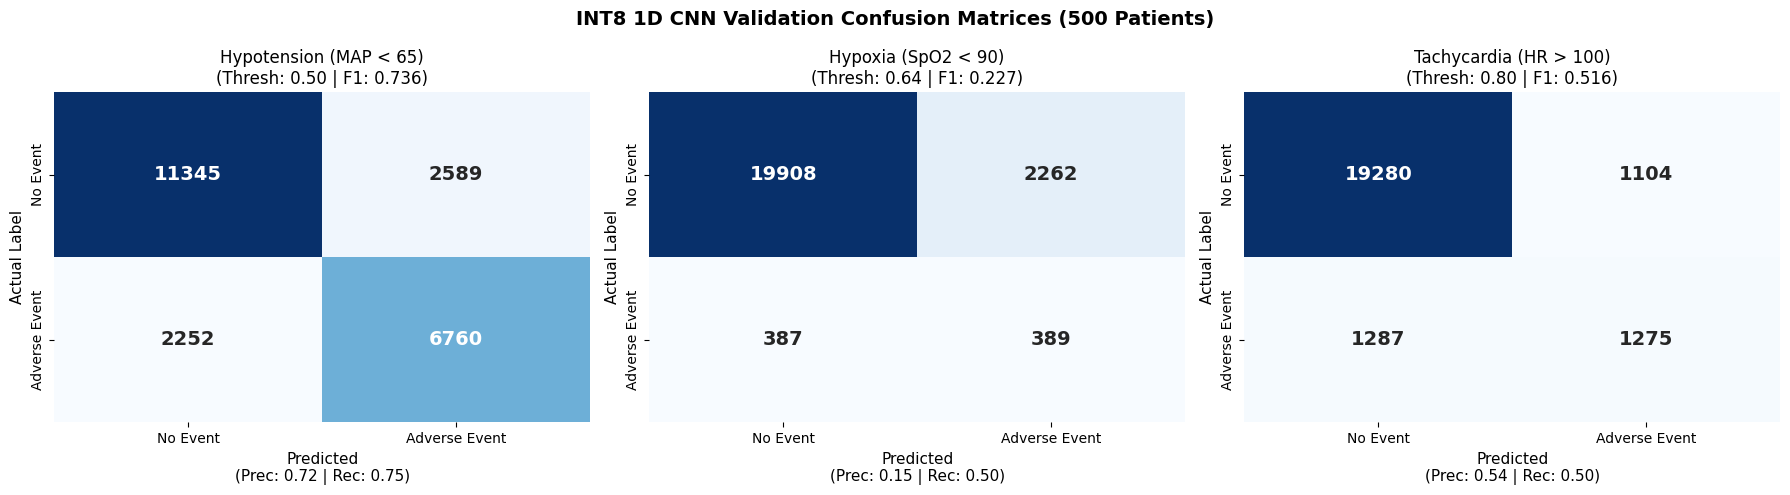

[Confusion Matrix Plot] Saved heatmap figure to: models_int8/confusion_matrices_int8.png


In [13]:
# Plotting Side-by-Side Confusion Matrices for all 3 Targets
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('INT8 1D CNN Validation Confusion Matrices (500 Patients)', fontsize=14, fontweight='bold')

target_titles = {
    'Future_Hypotension': 'Hypotension (MAP < 65)',
    'Future_Hypoxia': 'Hypoxia (SpO2 < 90)',
    'Future_Tachycardia': 'Tachycardia (HR > 100)'
}

for idx, target in enumerate(targets):
    ax = axes[idx]
    if target in evaluation_results:
        cm = evaluation_results[target]['cm']
        thresh = evaluation_results[target]['threshold']
        f1 = evaluation_results[target]['f1']
        prec = evaluation_results[target]['precision']
        rec = evaluation_results[target]['recall']
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                    xticklabels=['No Event', 'Adverse Event'],
                    yticklabels=['No Event', 'Adverse Event'],
                    annot_kws={'size': 14, 'weight': 'bold'})
        ax.set_title(f'{target_titles[target]}\n(Thresh: {thresh:.2f} | F1: {f1:.3f})', fontsize=12)
        ax.set_xlabel(f'Predicted\n(Prec: {prec:.2f} | Rec: {rec:.2f})', fontsize=11)
        ax.set_ylabel('Actual Label', fontsize=11)
    else:
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center')

plt.tight_layout()
cm_fig_path = os.path.join(MODEL_OUTPUT_DIR, 'confusion_matrices_int8.png')
plt.savefig(cm_fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'[Confusion Matrix Plot] Saved heatmap figure to: {cm_fig_path}')